El Objetivo: Tu tarea será agrupar a los clientes en diferentes segmentos basándote en su patrón de gasto a lo largo del tiempo. Por ejemplo:

- Clientes "Constantes": Compran una cantidad similar cada mes.

- Clientes "Estacionales": Solo compran en épocas específicas del año (como Navidad).

- Clientes "Crecientes": Su gasto aumenta mes a mes.

- Clientes "Durmientes": Compraban mucho y han dejado de hacerlo.

In [1]:
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import mlflow

import seaborn as sns

sns.set_style("whitegrid")

/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [1]:
url = "../data/raw/online_retail_II.xlsx"
sheets = ["Year 2009-2010", "Year 2010-2011"]

# Leer ambas hojas y concatenarlas
df = pd.concat([pd.read_excel(url, sheet_name=sheet) for sheet in sheets], ignore_index=True)

print(df.shape)
print(df.head())

(1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [3]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Preprocesamiento Basico

In [86]:
class FeatureEngineer:
    def __init__(self, raw_df):
        self.df = raw_df.copy()

    def __filter_data(self):
        
        # Eliminar filas con cantidades negativas o cero
        self.df = self.df[self.df["Quantity"] > 0]

        # Eliminar filas con valores nulos en 'Customer ID'
        self.df = self.df.dropna(subset=['Customer ID'])

    def __preprocess(self):

        # Convertir 'Customer ID' a entero
        self.df['Customer ID'] = self.df['Customer ID'].astype(int)
        
        # Convertir 'InvoiceDate' a datetime
        self.df['InvoiceDate'] = pd.to_datetime(self.df['InvoiceDate'])

        # Crear una nueva columna 'Sales'
        self.df['Sales'] = self.df['Quantity'] * self.df['Price']

        self.df = self.df[['Customer ID', 'InvoiceDate', 'Sales']]

    def __transform_series_time(self):
        self.__filter_data()
        self.__preprocess()

        # 2. ¡LA TRANSFORMACIÓN CLAVE con pivot_table!
        customer_monthly_sales = self.df.pivot_table(
            index='Customer ID',                              # <-- Cada fila será un cliente
            columns=pd.Grouper(key='InvoiceDate', freq='ME'), # <-- Cada columna será un mes
            values='Sales',                                   # <-- El valor en la celda será la venta
            aggfunc='sum'                                     # <-- Sumaremos las ventas de ese mes
        ).fillna(0)                                           # <-- Rellenar NaNs con 0 (sin ventas)
        return customer_monthly_sales
    
    def __filter_active_customers(self, min_active_months=5):

        customer_monthly_sales = self.__transform_series_time()

        # 1. Contar meses con actividad (ventas > 0)
        activity_counts = customer_monthly_sales[customer_monthly_sales > 0].count(axis=1)

        # 2. Definir un umbral mínimo de actividad.
        #    Vamos a requerir que un cliente haya comprado en al menos 5 meses.
        min_active_months = min_active_months

        # 3. Filtrar clientes activos
        active_customers = activity_counts[activity_counts >= min_active_months].index
        df_filtered = customer_monthly_sales.loc[active_customers]

        return df_filtered
    def run(self, min_active_months=5):
        return self.__filter_active_customers(min_active_months=min_active_months)

In [101]:
fe = FeatureEngineer(df)
df_filtered = fe.run(min_active_months=6)
print("Filtrado final:", df_filtered.shape)
df_filtered.head()

Filtrado final: (1488, 25)


InvoiceDate,2009-12-31,2010-01-31,2010-02-28,2010-03-31,2010-04-30,2010-05-31,2010-06-30,2010-07-31,2010-08-31,2010-09-30,...,2011-03-31,2011-04-30,2011-05-31,2011-06-30,2011-07-31,2011-08-31,2011-09-30,2011-10-31,2011-11-30,2011-12-31
Customer ID,,,,,,,,,,,,,,,,,,,,,
12347,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,636.25,0.00,382.52,0.00,584.91,0.00,1294.32,0.00,224.82
12359,838.89,0.0,0.0,683.34,0.0,0.00,489.80,0.0,0.00,0.0,...,0.0,0.00,0.00,1109.32,0.00,0.00,0.00,2876.85,0.00,0.00
12360,0.00,0.0,118.0,40.00,0.0,622.04,0.00,0.0,0.00,0.0,...,0.0,0.00,1083.58,0.00,0.00,534.70,0.00,1043.78,0.00,0.00
12362,130.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.0,...,0.0,495.24,0.00,0.00,303.76,469.25,829.99,1641.91,477.94,529.04
12380,0.00,0.0,3017.3,200.00,0.0,0.00,2597.35,0.0,1136.84,0.0,...,0.0,0.00,0.00,607.55,0.00,0.00,626.01,450.86,1040.39,0.00


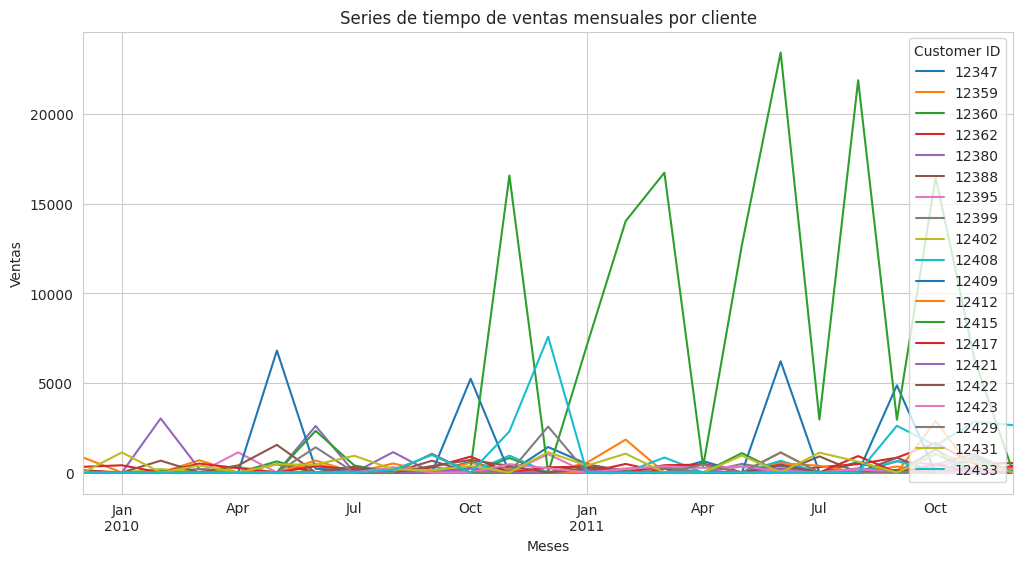

In [102]:
df_filtered.iloc[:20].T.plot(figsize=(12, 6))
plt.title("Series de tiempo de ventas mensuales por cliente")
plt.xlabel("Meses")
plt.ylabel("Ventas")
plt.show()

In [103]:
# 3. Escalar todas las series de tiempo a la vez.
#    mu=0.0, std=1.0 hace que se comporte exactamente como un StandardScaler.
print("Escalando con TimeSeriesScalerMeanVariance...")
scaler = TimeSeriesScalerMeanVariance(mu=0.0, std=1.0)

# Esta sola línea reemplaza todo el bucle.
# fit_transform se aplica a cada fila (serie) independientemente.
X_scaled = scaler.fit_transform(df_filtered)

print("¡Escalado completado!")
print(f"Forma de los datos escalados: {X_scaled.shape}")

Escalando con TimeSeriesScalerMeanVariance...


/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


¡Escalado completado!
Forma de los datos escalados: (1488, 25, 1)


In [104]:
X_data = pd.DataFrame(X_scaled[:, :, 0], index=df_filtered.index, columns=df_filtered.columns)
X_data.head()

InvoiceDate,2009-12-31,2010-01-31,2010-02-28,2010-03-31,2010-04-30,2010-05-31,2010-06-30,2010-07-31,2010-08-31,2010-09-30,...,2011-03-31,2011-04-30,2011-05-31,2011-06-30,2011-07-31,2011-08-31,2011-09-30,2011-10-31,2011-11-30,2011-12-31
Customer ID,,,,,,,,,,,,,,,,,,,,,
12347,-0.565013,-0.565013,-0.565013,-0.565013,-0.565013,-0.565013,-0.565013,-0.565013,-0.565013,-0.565013,...,-0.565013,1.030358,-0.565013,0.394141,-0.565013,0.901625,-0.565013,2.680442,-0.565013,-0.001286
12359,0.703507,-0.522295,-0.522295,0.476215,-0.522295,-0.522295,0.193410,-0.522295,-0.522295,-0.522295,...,-0.522295,-0.522295,-0.522295,1.098665,-0.522295,-0.522295,-0.522295,3.681413,-0.522295,-0.522295
12360,-0.500697,-0.500697,-0.153391,-0.382966,-0.500697,1.330137,-0.500697,-0.500697,-0.500697,-0.500697,...,-0.500697,-0.500697,2.688576,-0.500697,-0.500697,1.073072,-0.500697,2.571434,-0.500697,-0.500697
12362,-0.223585,-0.568586,-0.568586,-0.568586,-0.568586,-0.568586,-0.568586,-0.568586,-0.568586,-0.568586,...,-0.568586,0.745708,-0.568586,-0.568586,0.237548,0.676734,1.634085,3.788800,0.699796,0.835408
12380,-0.491807,-0.491807,3.342123,-0.237678,-0.491807,-0.491807,2.808514,-0.491807,0.952718,-0.491807,...,-0.491807,-0.491807,-0.491807,0.280176,-0.491807,-0.491807,0.303632,0.081078,0.830164,-0.491807


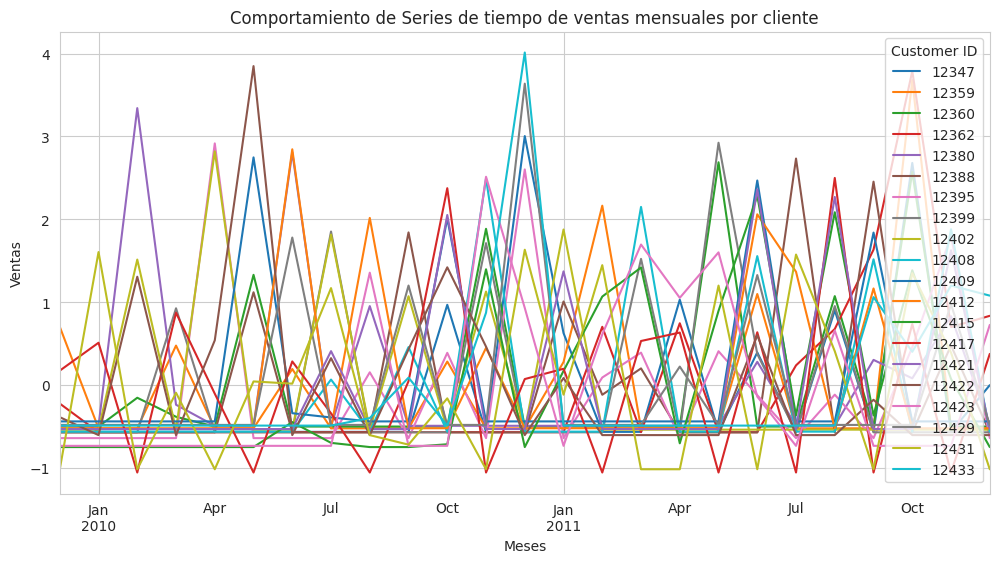

In [105]:
X_data.iloc[:20].T.plot(figsize=(12, 6))
plt.title("Comportamiento de Series de tiempo de ventas mensuales por cliente")
plt.xlabel("Meses")
plt.ylabel("Ventas")
plt.show()

In [106]:
N_CLUSTERS = 4

In [107]:
kmeans = TimeSeriesKMeans(n_clusters=N_CLUSTERS, metric="dtw", random_state=42)
kmeans.fit(X_data)
labels = kmeans.labels_
inertia = kmeans.inertia_
silhouette = silhouette_score(X_data, labels)
davies_bouldin = davies_bouldin_score(X_data, labels)

print(f"Inertia: {inertia}")
print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Score: {davies_bouldin}")


/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Inertia: 6.9462294186108995
Silhouette Score: 0.011209730316179549
Davies-Bouldin Score: 9.105153763082551


In [116]:
kmeans = KShape(n_clusters=N_CLUSTERS, random_state=42)
kmeans.fit(X_data)
labels = kmeans.labels_
inertia = kmeans.inertia_
silhouette = silhouette_score(X_data, labels)
davies_bouldin = davies_bouldin_score(X_data, labels)

print(f"Inertia: {inertia}")
print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Score: {davies_bouldin}")

/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/keras/wordspaces/ml2_clases/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: F

Inertia: 0.1601484974111117
Silhouette Score: -0.002458152705601726
Davies-Bouldin Score: 13.291945358669826


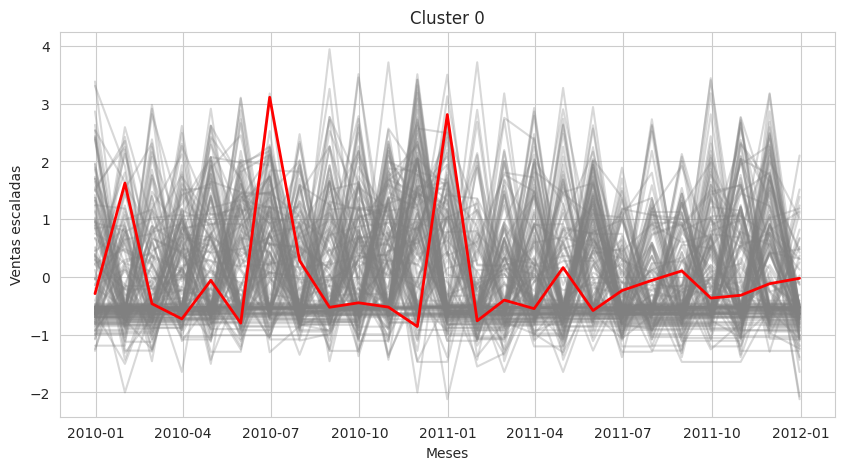

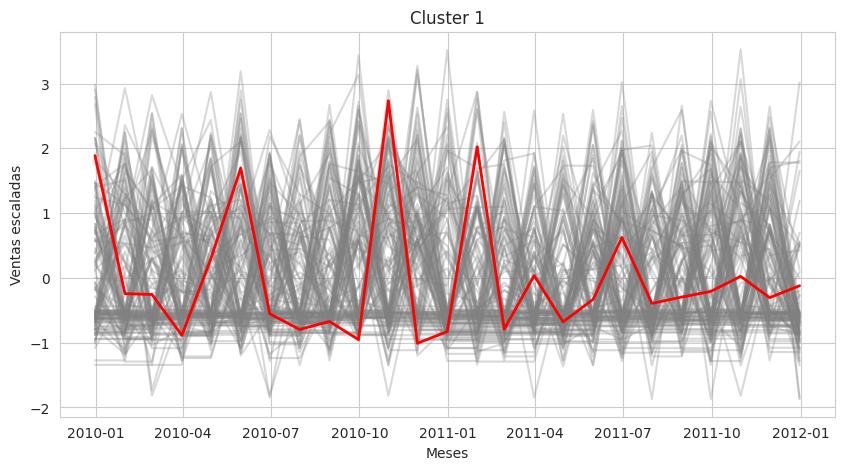

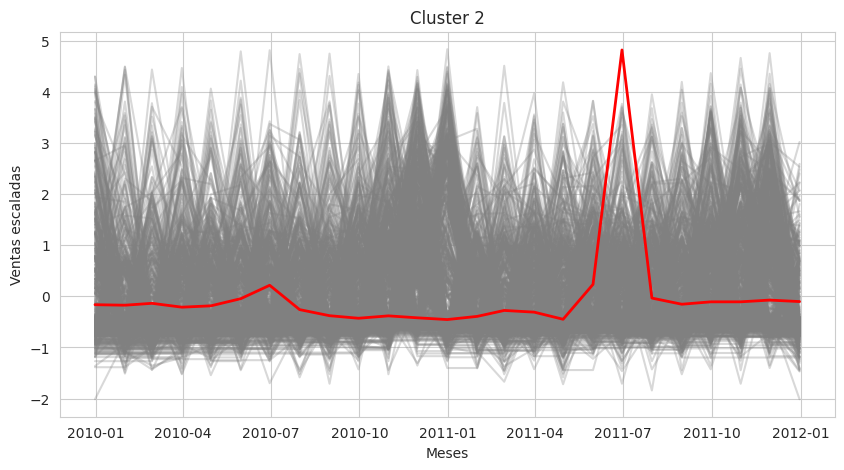

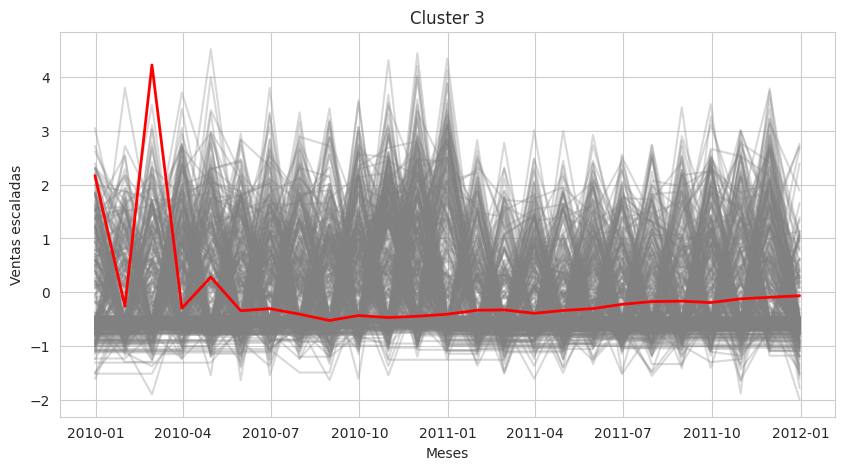

In [117]:
for cluster in range(N_CLUSTERS):
    plt.figure(figsize=(10, 5))
    for i in range(len(X_data)):
        if labels[i] == cluster:
            plt.plot(X_data.columns, X_data.iloc[i], color='gray', alpha=0.3)
    plt.plot(X_data.columns, kmeans.cluster_centers_[cluster], color='red', linewidth=2)
    plt.title(f"Cluster {cluster}")
    plt.xlabel("Meses")
    plt.ylabel("Ventas escaladas")
    plt.show()

In [ ]:
import mlflow
logged_model = 'runs:/13c4e8ff9f504bc8aabe1094801cc0bb/model'

# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)

# Predict on a Pandas DataFrame.
import pandas as pd


In [ ]:
loaded_model.predict(ts_data_df)

In [ ]:
venv/bin/pandas,sklearn

In [ ]:
requirements/projects -> venv/

In [ ]:
.lock